In [1]:
pip install --upgrade pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 52.5 MB/s eta 0:00:00:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pymupdf

doc = pymupdf.open("jurnal.pdf") # open a document
out = open("output.txt", "wb") # create a text output
for page in doc: # iterate the document pages
    text = page.get_text().encode("utf8") # get plain text (is in UTF-8)
    out.write(text) # write text of page
    out.write(bytes((12,))) # write page delimiter (form feed 0x0C)
out.close()

In [3]:
%%capture
!pip install nltk

In [4]:
import nltk
nltk.download('punkt')  # hanya perlu sekali
nltk.download('punkt_tab')  # opsional, untuk versi terbaru NLTK (≥3.8.2)

[nltk_data] Downloading package punkt to /home/codespace/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [5]:
with open('output.txt', 'r', encoding='utf-8') as file:
    teks = file.read()

print(teks[:200])  # tampilkan 200 karakter pertama

JURNAL EKSPLORA INFORMATIKA 
◼ 32 
 
p-ISSN: 2089-1814; e-ISSN: 2460-3694; DOI: 10.30864/eksplora.v10i1.390 
Analisis Sentimen pada Ulasan Pembelian Produk di 
Marketplace Shopee Menggunakan Pendekata


In [6]:
# Install: pip install nltk
import nltk


sentences = nltk.sent_tokenize(teks)
print(sentences)

['JURNAL EKSPLORA INFORMATIKA \n◼ 32 \n \np-ISSN: 2089-1814; e-ISSN: 2460-3694; DOI: 10.30864/eksplora.v10i1.390 \nAnalisis Sentimen pada Ulasan Pembelian Produk di \nMarketplace Shopee Menggunakan Pendekatan Natural \nLanguage Processing \n \n \nElik Hari Muktafin1, Kusrini2, Emha Taufiq Luthfi3 \nMagister Teknik Informatika \nUniversitas Amikom Yogyakarta \nYogyakarta, Indonesia \ne-mail: 1elik.muktafin@students.amikom.ac.id, 2kusrini@amikom.ac.id, 3emhataufiqluthfi@amikom.ac.id \n \nDiajukan: 1 Juli 2020; Direvisi: 7 Agustus 2020; Diterima: 15 Agustus 2020 \n \nAbstrak \nUlasan produk di marketplace merupakan informasi yang berharga apabila diolah dengan baik.', 'Penjual dapat melakukan analisis ulasan produk untuk mendapat informasi yang dapat digunakan dalam \nevaluasi produk dan layanan.', 'Kegiatan analisis ulasan produk tidak cukup dengan melihat jumlah bintang, \ndiperlukan melihat seluruh isi komentar ulasan untuk dapat mengetahui maksud dari ulasan.', 'Apabila \ndalam jumlah

In [7]:
import pandas as pd
df = pd.DataFrame(sentences, columns=['kalimat'])
print(df)

                                               kalimat
0    JURNAL EKSPLORA INFORMATIKA \n◼ 32 \n \np-ISSN...
1    Penjual dapat melakukan analisis ulasan produk...
2    Kegiatan analisis ulasan produk tidak cukup de...
3    Apabila \ndalam jumlah sedikit dapat dilakukan...
4    Dibutuhkan sistem yang mampu menganalisis bany...
..                                                 ...
380        1–13, 2018, doi: 10.14421/jiska.2018.31-01.
381  [31] J. Riany, M. Fajar, and M. P. Lukman, “Pe...
382                                            06, no.
383                                            01, pp.
384  147–156, 2016, doi: \n10.24089/j.sisfo.2016.09...

[385 rows x 1 columns]


In [8]:
df.to_csv('kalimat.csv', index=False, encoding='utf-8')

Untuk membuat word graph

Lanjutkan dengan menggunakan https://www.geeksforgeeks.org/nlp/co-occurence-matrix-in-nlp/

In [9]:
import pandas as pd

# 1. Read the 'kalimat.csv' file into a pandas DataFrame.
df_kalimat = pd.read_csv('kalimat.csv')

# 2. Access the 'kalimat' column and 3. Concatenate all text entries into a single string.
all_text = df_kalimat['kalimat'].str.cat(sep=' ')

print(f"First 500 characters of the concatenated text:\n{all_text[:500]}")

First 500 characters of the concatenated text:
JURNAL EKSPLORA INFORMATIKA 
◼ 32 
 
p-ISSN: 2089-1814; e-ISSN: 2460-3694; DOI: 10.30864/eksplora.v10i1.390 
Analisis Sentimen pada Ulasan Pembelian Produk di 
Marketplace Shopee Menggunakan Pendekatan Natural 
Language Processing 
 
 
Elik Hari Muktafin1, Kusrini2, Emha Taufiq Luthfi3 
Magister Teknik Informatika 
Universitas Amikom Yogyakarta 
Yogyakarta, Indonesia 
e-mail: 1elik.muktafin@students.amikom.ac.id, 2kusrini@amikom.ac.id, 3emhataufiqluthfi@amikom.ac.id 
 
Diajukan: 1 Juli 2020; Dir


In [10]:
import re
import string
import pandas as pd

df_to_clean = pd.read_csv('kalimat.csv')

def clean_text(text):
    # Pastikan input string
    if not isinstance(text, str):
        return ""

    # Hapus karakter spesifik
    text = text.replace('◼', '')

    # Deteksi kata berulang seperti "laki-laki", "pura-pura"
    # Pola: kata-kata yang sama dipisah tanda hubung
    text = re.sub(r'\b(\w+)-\1\b', r'\1', text)

    # Hapus punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Hapus angka
    text = re.sub(r'\d+', '', text)

    # Lowercase
    text = text.lower()

    # Hapus kata yang hanya satu huruf (mis. "v", "a", "b")
    text = re.sub(r'\b[a-zA-Z]\b', ' ', text)

    # Hilangkan spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    # --- Tambahan: hapus kata berulang berurutan + filter 1 huruf lagi (jaga-jaga) ---
    if text:
        tokens = text.split()

        cleaned_tokens = []
        prev = None
        for tok in tokens:
            # skip kalau hanya satu huruf
            if len(tok) == 1:
                continue
            # skip kalau sama dengan kata sebelumnya (kata berulang)
            if tok == prev:
                continue
            cleaned_tokens.append(tok)
            prev = tok

        text = " ".join(cleaned_tokens)
    # ----------------------------------------------------------------------

    return text

# Terapkan pembersihan
df_to_clean['cleaned_kalimat'] = df_to_clean['kalimat'].apply(clean_text)

# Simpan ke CSV
df_to_clean.to_csv('kalimat_cleaned.csv', index=False, encoding='utf-8')

print("Processed data with cleaned text saved to 'kalimat_cleaned.csv'")
print(df_to_clean[['kalimat', 'cleaned_kalimat']].head())

Processed data with cleaned text saved to 'kalimat_cleaned.csv'
                                             kalimat  \
0  JURNAL EKSPLORA INFORMATIKA \n◼ 32 \n \np-ISSN...   
1  Penjual dapat melakukan analisis ulasan produk...   
2  Kegiatan analisis ulasan produk tidak cukup de...   
3  Apabila \ndalam jumlah sedikit dapat dilakukan...   
4  Dibutuhkan sistem yang mampu menganalisis bany...   

                                     cleaned_kalimat  
0  jurnal eksplora informatika pissn eissn doi ek...  
1  penjual dapat melakukan analisis ulasan produk...  
2  kegiatan analisis ulasan produk tidak cukup de...  
3  apabila dalam jumlah sedikit dapat dilakukan s...  
4  dibutuhkan sistem yang mampu menganalisis bany...  


In [11]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import re # Import re for regex operations

nltk.download('punkt')
nltk.download('stopwords')

# Define stop_id and normalize_token function here for self-containment
stop_id = set(stopwords.words("indonesian"))

def normalize_token(tok: str) -> str:
    tok = tok.lower().strip()

    # only letters or letters-with-hyphens (e.g., laki-laki)
    if not re.fullmatch(r"[a-zA-Z]+(?:-[a-zA-Z]+)*", tok):
        return ""
    if tok in stop_id:
        return ""
    if len(tok) < 2:
        return ""
    return tok

# Load the cleaned data
df_cleaned = pd.read_csv('kalimat_cleaned.csv')

# Concatenate all cleaned text into a single string
all_cleaned_text = df_cleaned['cleaned_kalimat'].str.cat(sep=' ')

# Tokenize the concatenated text
raw_words = word_tokenize(all_cleaned_text)

# Apply normalization and filtering using the normalize_token function
words = [normalize_token(word) for word in raw_words]
words = [word for word in words if word] # Remove empty strings resulting from normalization

window_size = 3  # Meningkatkan ukuran jendela untuk hubungan kata yang lebih kaya

# 6. Membuat daftar pasangan kata yang muncul bersamaan
co_occurrences = defaultdict(Counter)
for i, word in enumerate(words):
    for j in range(max(0, i - window_size), min(len(words), i + window_size + 1)):
        if i != j:
            co_occurrences[word][words[j]] += 1

# 7. Membuat daftar kata unik
unique_words = list(set(words))

# 8. Inisialisasi matriks ko-okurensi
co_matrix = np.zeros((len(unique_words), len(unique_words)), dtype=int)

# 9. Membuat mapping dari kata ke indeks
word_index = {word: idx for idx, word in enumerate(unique_words)}

# 10. Mengisi matriks ko-okurensi
for word, neighbors in co_occurrences.items():
    for neighbor, count in neighbors.items():
        if neighbor in word_index:  # Pastikan kata tetangga ada dalam unique_words
            co_matrix[word_index[word]][word_index[neighbor]] = count

# 11. Membuat DataFrame agar lebih mudah dibaca
co_matrix_df = pd.DataFrame(co_matrix, index=unique_words, columns=unique_words)

# Menampilkan matriks ko-okurensi
print("Matriks Ko-okurensi")
print(co_matrix_df.iloc[:10, :10])
print("Total kata setelah preprocessing:", len(words))

Matriks Ko-okurensi
           ilmu  can  neighbor  appear  membuka  layanan  and  tokopedia  \
ilmu          0    0         0       0        0        0    0          0   
can           0    0         0       1        0        0    0          0   
neighbor      0    0         0       0        0        0    0          0   
appear        0    1         0       0        0        0    0          0   
membuka       0    0         0       0        0        0    0          0   
layanan       0    0         0       0        0        0    0          0   
and           0    0         0       0        0        0    0          0   
tokopedia     0    0         0       0        0        0    0          0   
konsumen      0    0         0       0        0        0    0          0   
pengaruh      0    0         0       0        0        0    2          0   

           konsumen  pengaruh  
ilmu              0         0  
can               0         0  
neighbor          0         0  
appear         

[nltk_data] Downloading package punkt to /home/codespace/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


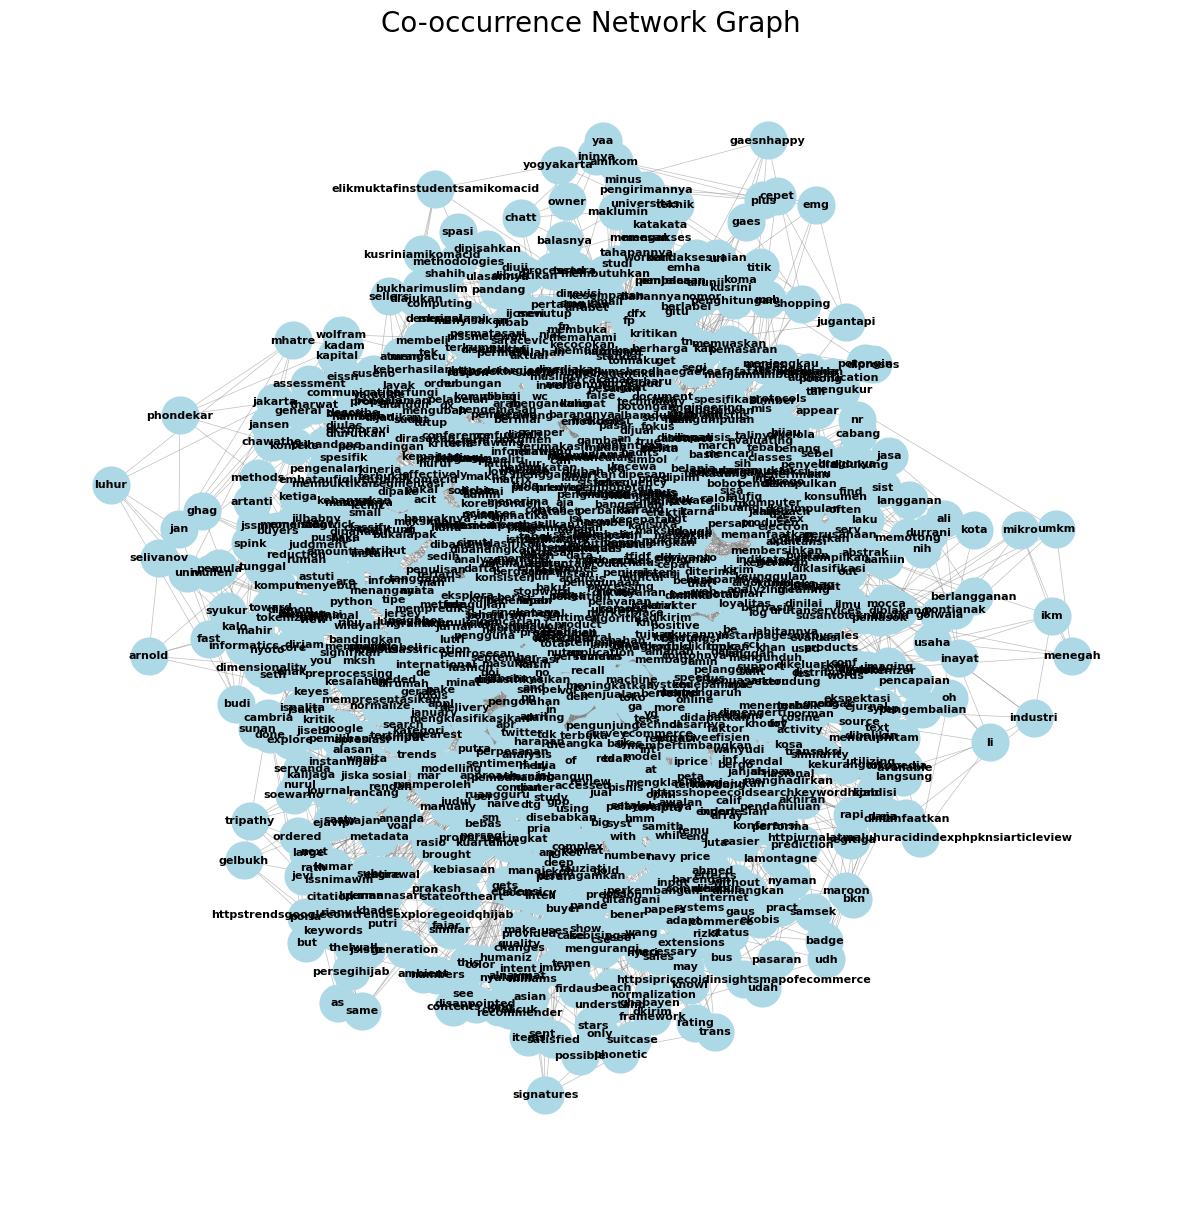

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.from_pandas_adjacency(co_matrix_df)

# Visualize the graph
plt.figure(figsize=(15, 15))
pos = nx.spring_layout(G, k=0.15, iterations=20) # positions for all nodes - k regulates the distance between nodes
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title("Co-occurrence Network Graph", size=20)
plt.axis('off') # Hide axes
plt.show()


In [13]:
pagerank_scores = nx.pagerank(G)
print("Hasil perhitungan PageRank untuk tiap node:")
for node, score in sorted(pagerank_scores.items(), key=lambda item: item[1], reverse=True)[:10]:
    print(f"{node}: {score:.4f}")

Hasil perhitungan PageRank untuk tiap node:
ulasan: 0.0331
produk: 0.0248
and: 0.0143
the: 0.0102
doi: 0.0085
no: 0.0078
pembeli: 0.0078
nlp: 0.0078
vol: 0.0072
pp: 0.0064


In [15]:
import pandas as pd

# 1. Membuat DataFrame pandas dari dictionary pagerank_scores
pagerank_df = pd.DataFrame(
    list(pagerank_scores.items()),
    columns=['Kata', 'Skor PageRank']
)

# 2. Mengurutkan DataFrame berdasarkan 'Skor PageRank' secara menurun
pagerank_df = pagerank_df.sort_values(
    by='Skor PageRank',
    ascending=False
)

# 3. Menampilkan 20 kata teratas
print("20 kata dengan Skor PageRank tertinggi:")
print(pagerank_df.head(20).reset_index(drop=True))


20 kata dengan Skor PageRank tertinggi:
           Kata  Skor PageRank
0        ulasan       0.033135
1        produk       0.024768
2           and       0.014312
3           the       0.010182
4           doi       0.008469
5            no       0.007835
6       pembeli       0.007808
7           nlp       0.007797
8           vol       0.007199
9            pp       0.006362
10      positif       0.006336
11         data       0.006330
12           of       0.006305
13        bagus       0.006094
14  marketplace       0.006013
15      bintang       0.006009
16     analisis       0.005899
17   pendekatan       0.005749
18        hasil       0.005681
19       shopee       0.005539


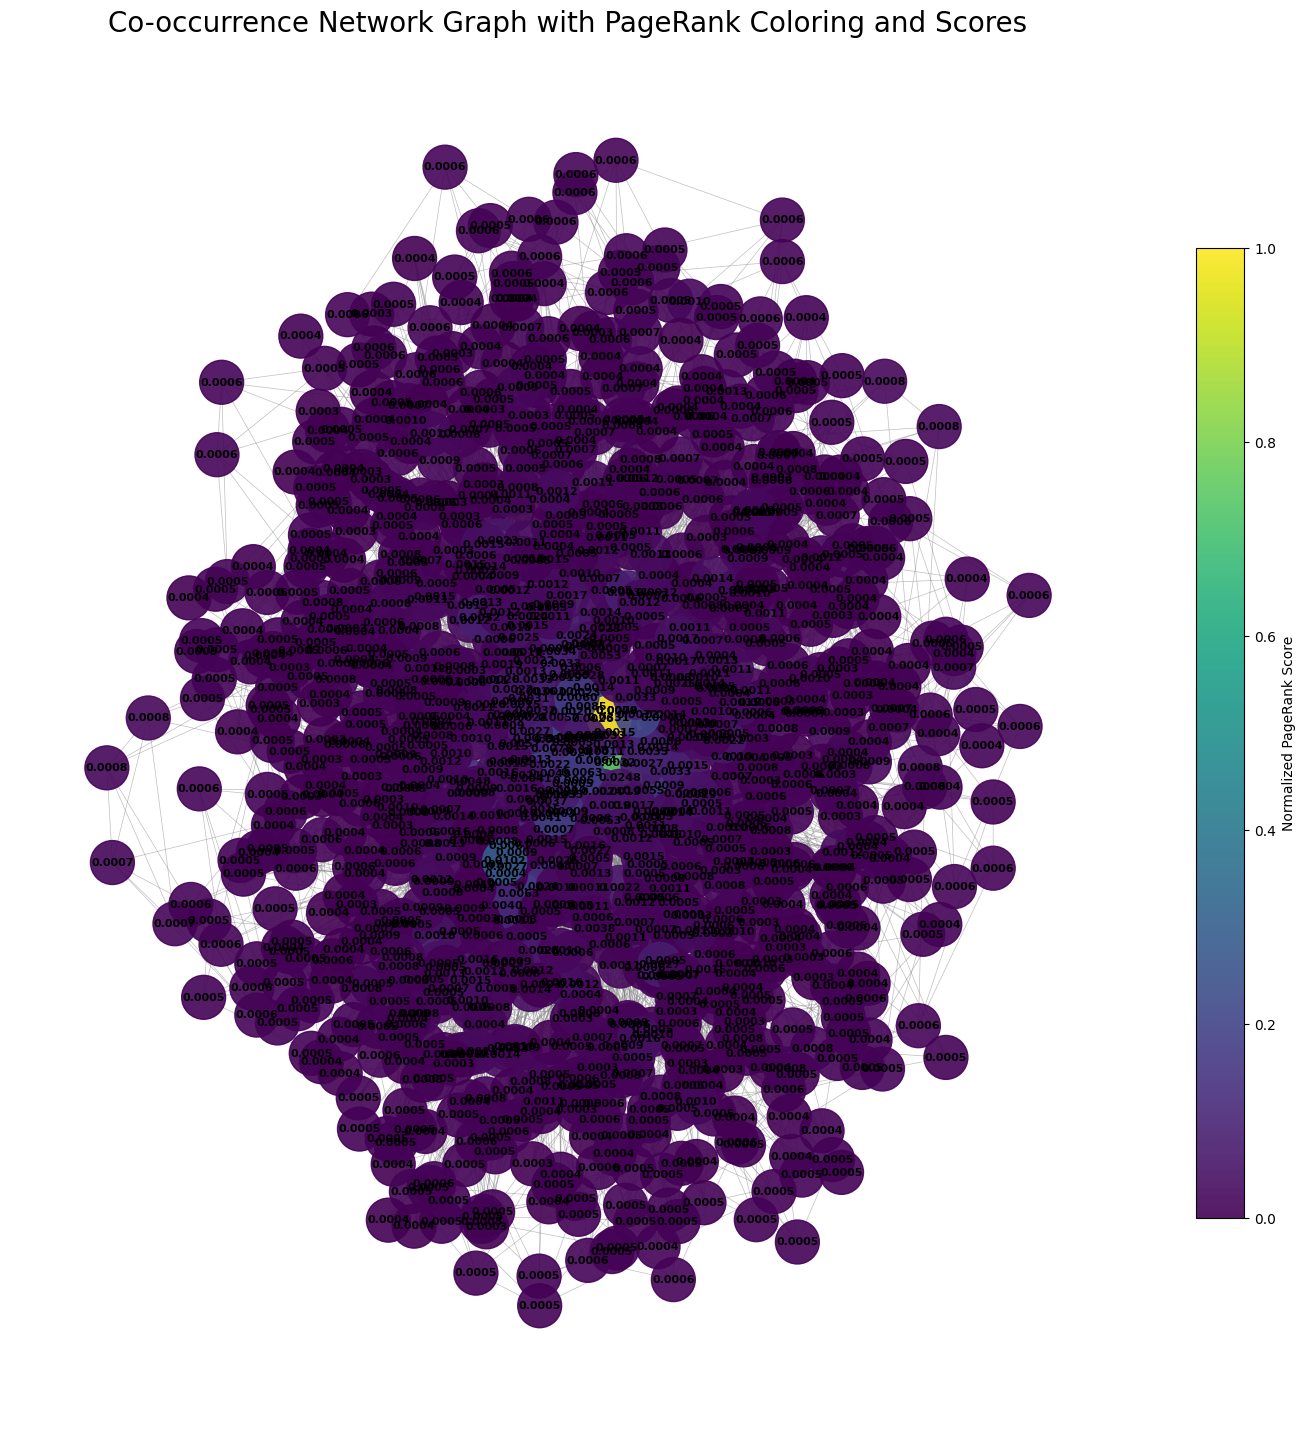

In [16]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Get PageRank scores from the previously calculated pagerank_scores dictionary
pagerank_values = list(pagerank_scores.values())

# Normalize PageRank scores for coloring (0 to 1 range)
# Avoid division by zero if all scores are the same or zero
if len(set(pagerank_values)) > 1:
    scores_norm = (pagerank_values - np.min(pagerank_values)) / (np.max(pagerank_values) - np.min(pagerank_values))
else:
    scores_norm = np.zeros_like(pagerank_values) # If all scores are same, set to 0

node_colors = [scores_norm[list(pagerank_scores.keys()).index(node)] for node in G.nodes()]

plt.figure(figsize=(18, 18))
pos = nx.spring_layout(G, k=0.15, iterations=20)

# Create labels dictionary with PageRank scores
# Ensure all nodes in G are present in pagerank_scores before creating labels
labels = {node: f'{pagerank_scores.get(node, 0):.4f}' for node in G.nodes()}

# Draw nodes with colors based on PageRank score
nodes = nx.draw_networkx_nodes(G, pos, node_size=1000, node_color=node_colors, cmap=plt.cm.viridis, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_weight='bold')

plt.title("Co-occurrence Network Graph with PageRank Coloring and Scores", size=20)
plt.axis('off')

# Add a color bar to show PageRank scale
cbar = plt.colorbar(nodes, shrink=0.7)
cbar.set_label('Normalized PageRank Score')

plt.show()

Stopwords + fungsi clean token (node harus kata jelas, tanpa angka/karakter aneh)

In [17]:
import re
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# kalau belum pernah:
# nltk.download("punkt")
# nltk.download("stopwords")

# 1) Load data
df = pd.read_csv("kalimat_cleaned.csv")
texts = df["kalimat"].dropna().astype(str).tolist()
print("Jumlah kalimat:", len(texts))

# 2) Stopwords Indonesia
stop_id = set(stopwords.words("indonesian"))

# 3) Blacklist metadata jurnal
blacklist = {
    "doi", "issn", "jurnal", "volume", "nomor",
    "abstrak", "email", "universitas", "indonesia",
    "yogyakarta", "alamat", "tanggal", "diterima",
    "direvisi", "diajukan","ya","the",'at','leee'
}

# 4) Normalisasi token FINAL
def normalize_token(tok: str) -> str:
    tok = tok.lower().strip()

    if not re.fullmatch(r"[a-zA-Z]+", tok):
        return ""
    if tok in stop_id:
        return ""
    if tok in blacklist:
        return ""
    if len(tok) < 2:
        return ""

    return tok

# 5) Normalisasi SEMUA kalimat
normalized_sentences = []

for t in texts:
    raw = word_tokenize(t)
    clean = [normalize_token(x) for x in raw]
    clean = [x for x in clean if x]
    normalized_sentences.append(" ".join(clean))

# 6) Simpan ke CSV
df_out = pd.DataFrame({
    "kalimat_normalized": normalized_sentences
})

df_out.to_csv("kalimat_normalized.csv", index=False, encoding="utf-8")

print("File berhasil disimpan: kalimat_normalized.csv")

# 7) Tampilkan contoh hasil (head)
print("\nContoh hasil normalisasi (1 kalimat):")
print(df_out.iloc[0, 0])

print("\nToken head 5 dari kalimat pertama:")
print(df_out.iloc[0, 0].split()[:5])


Jumlah kalimat: 385
File berhasil disimpan: kalimat_normalized.csv

Contoh hasil normalisasi (1 kalimat):
eksplora informatika analisis sentimen ulasan pembelian produk marketplace shopee pendekatan natural language processing elik emha taufiq magister teknik informatika amikom juli agustus agustus ulasan produk marketplace informasi berharga diolah

Token head 5 dari kalimat pertama:
['eksplora', 'informatika', 'analisis', 'sentimen', 'ulasan']


Tokenisasi + bikin bigram (1 token 2 kata) lalu gabung unigram+bigrams

In [18]:
all_sent_tokens = []

for t in texts:
    raw = word_tokenize(t)
    toks = [normalize_token(x) for x in raw]
    toks = [x for x in toks if x]

    bigrams = [f"{toks[i]} {toks[i+1]}" for i in range(len(toks)-1)]

    combined = toks + bigrams  # gabung 1 token 1 kata + 1 token 2 kata

    if combined:
        all_sent_tokens.append(combined)

print("Kalimat valid (punya token):", len(all_sent_tokens))
print("Contoh tokens:", all_sent_tokens[0][:25] if all_sent_tokens else "Tidak ada token")


Kalimat valid (punya token): 347
Contoh tokens: ['eksplora', 'informatika', 'analisis', 'sentimen', 'ulasan', 'pembelian', 'produk', 'marketplace', 'shopee', 'pendekatan', 'natural', 'language', 'processing', 'elik', 'emha', 'taufiq', 'magister', 'teknik', 'informatika', 'amikom', 'juli', 'agustus', 'agustus', 'ulasan', 'produk']


Bangun co-occurrence matrix -> graph (hubungan kata dengan kata)

In [19]:
window_size = 3  # bisa 2-5
edge_counter = Counter()
node_counter = Counter()

for tokens in all_sent_tokens:
    node_counter.update(tokens)
    n = len(tokens)
    for i in range(n):
        for j in range(i+1, min(i+window_size, n)):
            a, b = tokens[i], tokens[j]
            if a != b:
                edge_counter[(a, b)] += 1

print("Total kandidat node:", len(node_counter))
print("Total kandidat edge:", len(edge_counter))


Total kandidat node: 3043
Total kandidat edge: 9072


Filter node/edge biar bersih + bentuk graph final

In [20]:
min_node_freq = 2
min_edge_weight = 2

valid_nodes = {n for n, c in node_counter.items() if c >= min_node_freq}

G = nx.Graph()
for n in valid_nodes:
    G.add_node(n, freq=node_counter[n])

for (a, b), w in edge_counter.items():
    if w >= min_edge_weight and a in valid_nodes and b in valid_nodes:
        G.add_edge(a, b, weight=w)

print("Jumlah node:", G.number_of_nodes())
print("Jumlah edge:", G.number_of_edges())


Jumlah node: 788
Jumlah edge: 997


Node dan edge

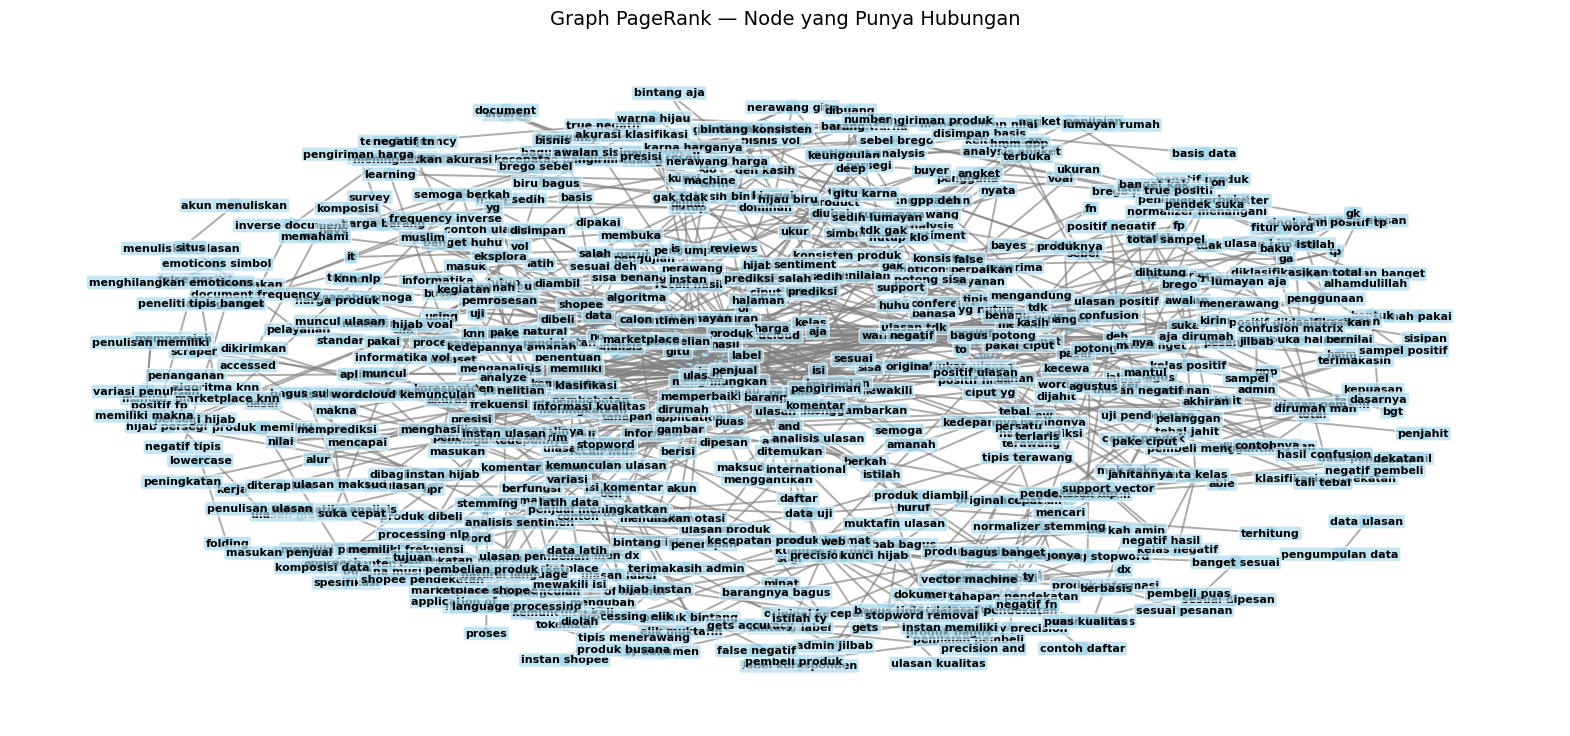

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

# hanya node yang punya hubungan
nodes_with_edges = [n for n in G.nodes() if G.degree(n) > 0]
G_plot = G.subgraph(nodes_with_edges).copy()

# HITUNG PAGERANK DARI GRAPH YANG SAMA
pr = nx.pagerank(G_plot, weight="weight")

pos = nx.spring_layout(G_plot, seed=42, k=0.35)

pr_values = np.array(list(pr.values()))
pr_max = pr_values.max() if pr_values.size else 1.0

node_sizes = [
    1800 * ((pr[n] / pr_max) + 0.03)
    for n in G_plot.nodes()
]

plt.figure(figsize=(20, 9))
ax = plt.gca()

# NODE
nx.draw_networkx_nodes(
    G_plot, pos,
    node_size=node_sizes,
    node_color="#a6d8ec",
    edgecolors="white",
    linewidths=1.2,
    alpha=0.95,
    ax=ax
)

# EDGE
edge_artist = nx.draw_networkx_edges(
    G_plot, pos,
    alpha=0.65,
    width=1.4,
    edge_color="gray",
    ax=ax
)

try:
    edge_artist.set_zorder(3)
except:
    pass

# LABEL
nx.draw_networkx_labels(
    G_plot, pos,
    font_size=8,
    font_weight="bold",
    bbox=dict(
        facecolor="#a6d8ec",
        edgecolor="white",
        boxstyle="round,pad=0.20",
        alpha=0.65
    ),
    ax=ax
)

plt.title("Graph PageRank — Node yang Punya Hubungan", fontsize=14)
plt.axis("off")
plt.show()


Centrality (PageRank, Degree, Betweenness, Closeness)

In [24]:
pagerank_scores = nx.pagerank(G, weight="weight")
degree_c = nx.degree_centrality(G)
between_c = nx.betweenness_centrality(G, weight="weight", normalized=True)
close_c = nx.closeness_centrality(G)


Output nilai PageRank tiap node

In [25]:
result = pd.DataFrame({
    "node": list(G.nodes()),
    "freq": [G.nodes[n].get("freq", 0) for n in G.nodes()],
    "pagerank": [pagerank_scores.get(n, 0.0) for n in G.nodes()],
    "degree_centrality": [degree_c.get(n, 0.0) for n in G.nodes()],
    "betweenness_centrality": [between_c.get(n, 0.0) for n in G.nodes()],
    "closeness_centrality": [close_c.get(n, 0.0) for n in G.nodes()],
}).sort_values("pagerank", ascending=False).reset_index(drop=True)

display(result.head(30))


,node,freq,pagerank,degree_centrality,betweenness_centrality,closeness_centrality
0,ulasan,162,0.029568,0.100381,0.116181,0.196817
1,produk,120,0.021813,0.072427,0.072337,0.186428
2,bagus,28,0.010256,0.038119,0.027718,0.163105
3,pembeli,37,0.007390,0.033037,0.033033,0.168043
4,negatif,27,0.006622,0.024142,0.019840,0.167176
5,positif,32,0.006210,0.024142,0.012272,0.165608
6,banget,23,0.005878,0.021601,0.011609,0.136130
7,nlp,37,0.005778,0.025413,0.024895,0.136898
8,kualitas,24,0.005412,0.016518,0.005907,0.157677
9,bintang,29,0.005318,0.020330,0.009701,0.157421


Ambil 20 kata penting (unik) dari graph (berdasarkan PageRank)

In [26]:
top20 = result.head(20).copy()
display(top20)

print("Top 20 nodes:")
print(top20["node"].tolist())


,node,freq,pagerank,degree_centrality,betweenness_centrality,closeness_centrality
0,ulasan,162,0.029568,0.100381,0.116181,0.196817
1,produk,120,0.021813,0.072427,0.072337,0.186428
2,bagus,28,0.010256,0.038119,0.027718,0.163105
3,pembeli,37,0.007390,0.033037,0.033033,0.168043
4,negatif,27,0.006622,0.024142,0.019840,0.167176
5,positif,32,0.006210,0.024142,0.012272,0.165608
6,banget,23,0.005878,0.021601,0.011609,0.136130
7,nlp,37,0.005778,0.025413,0.024895,0.136898
8,kualitas,24,0.005412,0.016518,0.005907,0.157677
9,bintang,29,0.005318,0.020330,0.009701,0.157421


Top 20 nodes:
['ulasan', 'produk', 'bagus', 'pembeli', 'negatif', 'positif', 'banget', 'nlp', 'kualitas', 'bintang', 'hasil', 'analisis', 'marketplace', 'data', 'sentimen', 'pendekatan', 'kualitas produk', 'pembelian', 'language', 'pendekatan nlp']


In [27]:
import re

# fungsi filter node penting (berdasarkan isi node)
def is_kalimat_penting(node: str) -> bool:
    node = node.lower()

    # buang url / noise teknis
    blacklist_fragment = [
        "http", "www", "search", "google", "insta", "page",
        "token", "assessment", "tools", "keyword", "sales"
    ]
    if any(b in node for b in blacklist_fragment):
        return False

    # hanya huruf + spasi (untuk bigram)
    if not re.fullmatch(r"[a-zA-Z ]+", node):
        return False

    # minimal panjang (biar bukan kata receh)
    if len(node) < 5:
        return False

    return True


# filter dari result PageRank
important_nodes = result[result["node"].apply(is_kalimat_penting)]

# ambil top 20 berdasarkan PageRank
top20_penting = important_nodes.head(20).copy()

display(top20_penting)

print("Top 20 kalimat/kata penting:")
print(top20_penting["node"].tolist())


,node,freq,pagerank,degree_centrality,betweenness_centrality,closeness_centrality
0,ulasan,162,0.029568,0.100381,0.116181,0.196817
1,produk,120,0.021813,0.072427,0.072337,0.186428
2,bagus,28,0.010256,0.038119,0.027718,0.163105
3,pembeli,37,0.007390,0.033037,0.033033,0.168043
4,negatif,27,0.006622,0.024142,0.019840,0.167176
5,positif,32,0.006210,0.024142,0.012272,0.165608
6,banget,23,0.005878,0.021601,0.011609,0.136130
8,kualitas,24,0.005412,0.016518,0.005907,0.157677
9,bintang,29,0.005318,0.020330,0.009701,0.157421
10,hasil,29,0.005259,0.021601,0.011092,0.141073


Top 20 kalimat/kata penting:
['ulasan', 'produk', 'bagus', 'pembeli', 'negatif', 'positif', 'banget', 'kualitas', 'bintang', 'hasil', 'analisis', 'marketplace', 'sentimen', 'pendekatan', 'kualitas produk', 'pembelian', 'language', 'pendekatan nlp', 'stemming', 'natural']


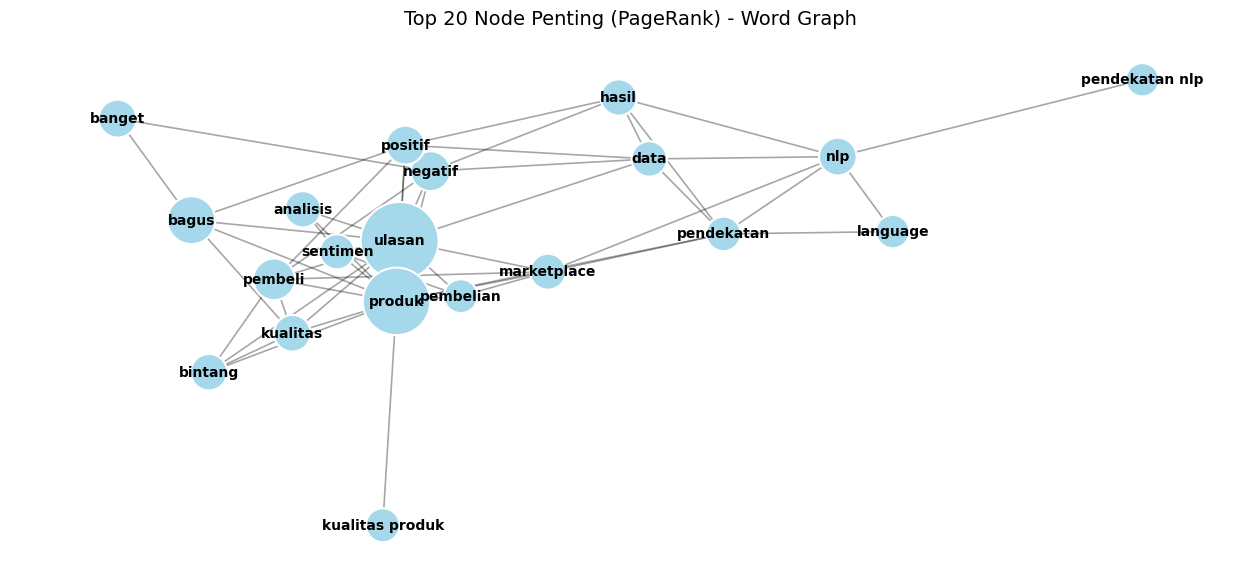

Top 20 nodes:
['ulasan', 'produk', 'bagus', 'pembeli', 'negatif', 'positif', 'banget', 'nlp', 'kualitas', 'bintang', 'hasil', 'analisis', 'marketplace', 'data', 'sentimen', 'pendekatan', 'kualitas produk', 'pembelian', 'language', 'pendekatan nlp']


In [28]:
import matplotlib.pyplot as plt
import networkx as nx

# 1) Ambil Top 20 dari result (sudah urut pagerank desc)
top20 = result.head(20).copy()
top20_nodes = top20["node"].tolist()

# 2) Subgraph hanya Top 20
H = G.subgraph(top20_nodes).copy()

# 3) Ambil skor PageRank buat node size
pr = dict(zip(top20["node"], top20["pagerank"]))

# kalau ada node yang tidak kebawa (harusnya nggak), kasih default kecil
for n in H.nodes():
    pr.setdefault(n, 0.0)

# 4) Skala ukuran node biar kelihatan (ubah kalau kekecilan/kegedean)
node_sizes = [3000 * (pr[n] / max(pr.values()) + 0.05) for n in H.nodes()]

# 5) Layout (biar mirip gaya gambar)
pos = nx.spring_layout(H, seed=42, k=0.8)

plt.figure(figsize=(16, 7))
nx.draw_networkx_edges(H, pos, alpha=0.35, width=1.2)

nx.draw_networkx_nodes(
    H, pos,
    node_size=node_sizes,
    node_color="#a6d8ec",   # biru muda kayak gambar
    edgecolors="white",
    linewidths=1.5
)

nx.draw_networkx_labels(
    H, pos,
    font_size=10,
    font_weight="bold"
)

plt.title("Top 20 Node Penting (PageRank) - Word Graph", fontsize=14)
plt.axis("off")
plt.show()

print("Top 20 nodes:")
print(top20_nodes)
